In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import warnings

---
## I. GRADIENT DESCENT VÀ HẠN CHẾ

### 1.1 Thuật toán Gradient Descent chuẩn

Quy tắc cập nhật:
$$\mathbf{x}_{t+1} = \mathbf{x}_t - \eta \nabla f(\mathbf{x}_t)$$

**Hạn chế chính của GD cơ bản:**
- **Hiện tượng Zig-zag**: Khi bề mặt hàm số có hình elip dẹt (condition number lớn), gradient luôn vuông góc với đường đồng mức, khiến quỹ đạo dao động qua lại thay vì đi thẳng về cực tiểu.
- **Hội tụ chậm**: Tốc độ hội tụ bị giới hạn bởi chiều "hẹp" của hàm số.
- **Nhạy cảm với learning rate**: Quá lớn thì phân kỳ, quá nhỏ thì hội tụ chậm.


In [5]:
def f_elip(x,y):
    return x**2 + 10*y**2

def grad_elip(x, y):
    return np.array([2*x, 20*y])

def gd(x_init, y_init, lr, steps, cond):
    path = [(x_init, y_init)]
    x, y = x_init, y_init
    prev_loss = f_elip(x, y)

    for _ in range(steps):
        grad = grad_elip(x, y)
        x_new = x - lr * grad[0]
        y_new = y - lr * grad[1]
        current_loss = f_elip(x_new, y_new)

        if abs(prev_loss - current_loss) < cond:
            x, y = x_new, y_new
            path.append((x, y))
            break
        prev_loss = current_loss
        x, y = x_new, y_new
        path.append((x, y))
    return np.array(path)

In [6]:
x_range = np.linspace(-1.2, 1.2, 200)
y_range = np.linspace(-1.2, 1.2, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = f_elip(X, Y)
path_gd = gd(-1.0, -1.0, lr=0.09, steps=50, cond=1e-6)

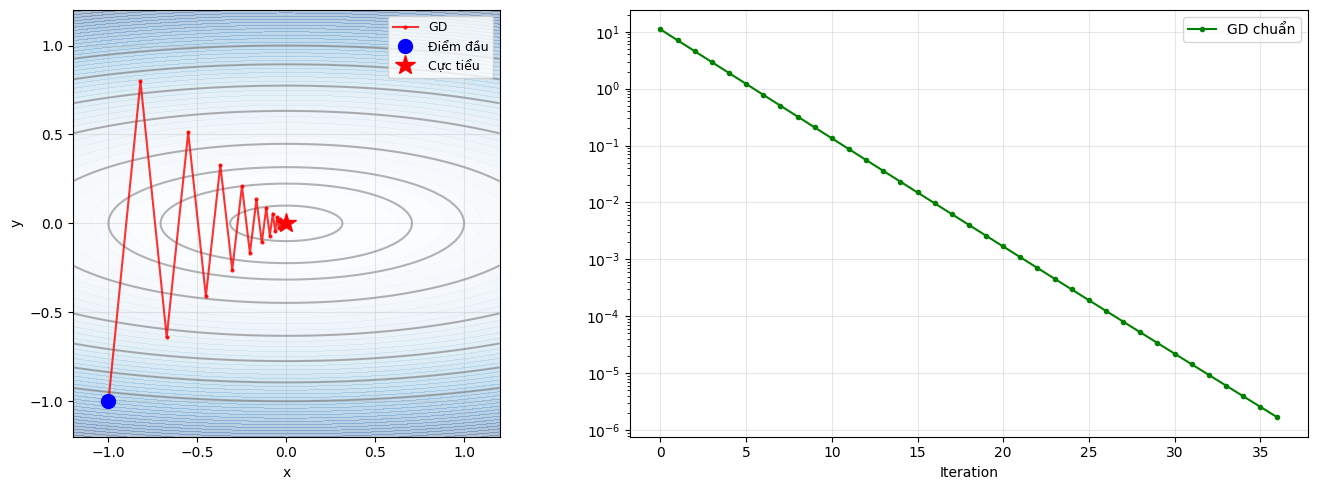

GD sau 36 bước: f = 0.000002


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  G1
ax = axes[0]
levels = [0.1, 0.5, 1, 2, 4, 6, 8, 10]
ax.contour(X, Y, Z, levels=levels, colors='gray', alpha=0.6)
ax.contourf(X, Y, Z, levels=50, cmap='Blues', alpha=0.3)
ax.plot(path_gd[:, 0], path_gd[:, 1], 'r.-', markersize=4, linewidth=1.5,
        label='GD', alpha=0.8)
ax.plot(path_gd[0, 0], path_gd[0, 1], 'bo', markersize=10, label='Điểm đầu')
ax.plot(0, 0, 'r*', markersize=15, label='Cực tiểu')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# G2
ax2 = axes[1]
losses_gd = [f_elip(p[0], p[1]) for p in path_gd]
ax2.semilogy(losses_gd, 'g-o', markersize=3, linewidth=1.5, label='GD chuẩn')
ax2.set_xlabel('Iteration')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GD sau {len(losses_gd) - 1} bước: f = {losses_gd[-1]:.6f}")

---
## II. MOMENTUM



### 2.1 Ý tưởng trực giác

> **Hình ảnh trực giác**: Tưởng tượng một quả bóng lăn xuống dốc. Quả bóng không dừng lại và đổi hướng ngay lập tức khi gặp địa hình mới – nó giữ **quán tính** (momentum) từ hướng di chuyển trước và chỉ dần dần điều chỉnh theo lực tác dụng mới.



### 2.2 Công thức toán học

**Gradient Descent chuẩn:**
$$\mathbf{x}_{t+1} = \mathbf{x}_t - \eta \nabla f(\mathbf{x}_t)$$

**Gradient Descent với Momentum:**
$$\mathbf{v}_t = \gamma \mathbf{v}_{t-1} + \eta \nabla f(\mathbf{x}_t)$$
$$\mathbf{x}_{t+1} = \mathbf{x}_t - \mathbf{v}_t $$

Trong đó:
- $\mathbf{v}_t$: **vector vận tốc** (velocity) tại bước $t$, khởi tạo $\mathbf{v}_0 = \mathbf{0}$
- $\beta \in [0, 1)$: **hệ số momentum** (thường chọn $\beta = 0.9$)
- $\eta > 0$: tốc độ học
- $\nabla f(\mathbf{x}_t)$: gradient tại vị trí hiện tại

### 2.3 Phân tích cơ chế

**Mở rộng công thức vận tốc:**
$$\mathbf{v}_{t+1} = -\eta \sum_{k=0}^{t} \beta^{t-k} \nabla f(\mathbf{x}_k)$$

Vector vận tốc là **tổng có trọng số hàm mũ** của tất cả các gradient trong quá khứ. Gradient gần đây có ảnh hưởng lớn hơn gradient xa xưa.

**Hai hiệu ứng chính:**
1. **Triệt tiêu dao động**: Gradient theo chiều thẳng góc (chiều zig-zag) thường đổi dấu liên tục → tổng triệt tiêu nhau → giảm dao động
2. **Tích lũy theo chiều hội tụ**: Gradient theo chiều hướng về cực tiểu luôn cùng dấu → tổng tích lũy → tăng tốc


In [8]:
start_pos = np.array([1.0, 1.0])
iterations = 50
lr = 0.01
gamma = 0.65

In [9]:
path = [start_pos.copy()]
path_m = [start_pos.copy()]
curr_gd = start_pos.copy()
curr_m = start_pos.copy()
v = np.zeros(2)

In [10]:
def simple_gd(start_pos, lr, iterations, tol=1e-3, cond = True):
    path = [start_pos.copy()]
    curr = start_pos.copy()
    prev_loss = f_elip(curr[0], curr[1])

    for i in range(iterations):
        g = grad_elip(curr[0], curr[1])
        curr -= lr * g
        path.append(curr.copy())

        cur_loss = f_elip(curr[0], curr[1])
        if abs(prev_loss - cur_loss) < tol and cond:
            print(f" Stop at round {i}")
            break
        prev_loss = cur_loss

    return np.array(path)

def simple_m(start_pos, lr, gamma, iterations, tol=1e-3, cond = True):
    path = [start_pos.copy()]
    curr = start_pos.copy()
    v = np.zeros_like(start_pos)
    prev_loss = f_elip(curr[0], curr[1])

    for i in range(iterations):
        g = grad_elip(curr[0], curr[1])
        v = gamma * v + lr * g
        curr -= v
        path.append(curr.copy())

        cur_loss = f_elip(curr[0], curr[1])
        if abs(prev_loss - cur_loss) < tol and cond:
            print(f" Stop at round {i}")
            break
        prev_loss = cur_loss

    return np.array(path)

In [11]:
path_gd = simple_gd(start_pos, lr, iterations)
path_momentum = simple_m(start_pos, lr, gamma, iterations)

 Stop at round 39


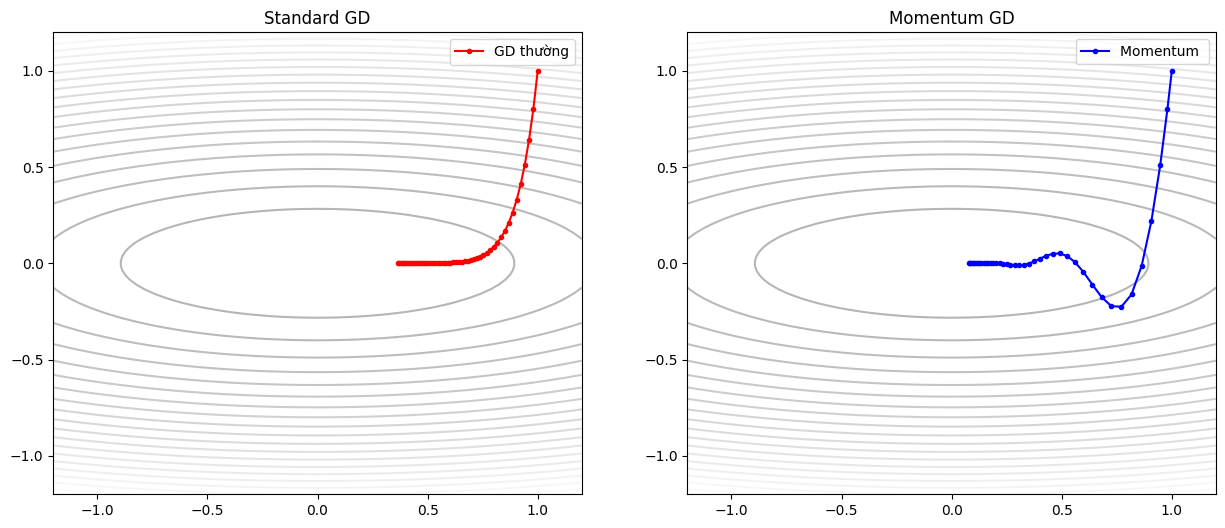

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x = np.linspace(-1.2, 1.2, 100)
y = np.linspace(-1.2, 1.2, 100)
X, Y = np.meshgrid(x, y)
Z = f_elip(X, Y)

#g1
ax[0].contour(X, Y, Z, levels=20, cmap='gray', alpha=0.3)
ax[0].plot(path_gd[:,0], path_gd[:,1], 'r.-', label='GD thường')
ax[0].set_title('Standard GD')
ax[0].legend()

#g2
ax[1].contour(X, Y, Z, levels=20, cmap='gray', alpha=0.3)
ax[1].plot(path_momentum[:,0], path_momentum[:,1], 'b.-', label='Momentum ')
ax[1].set_title('Momentum GD')
ax[1].legend()

In [13]:
path_gd = simple_gd(start_pos, lr = 0.05, iterations = 100)
path_momentum = simple_m(start_pos, lr = 0.05, gamma = 0.90, iterations = 100)

 Stop at round 25
 Stop at round 69


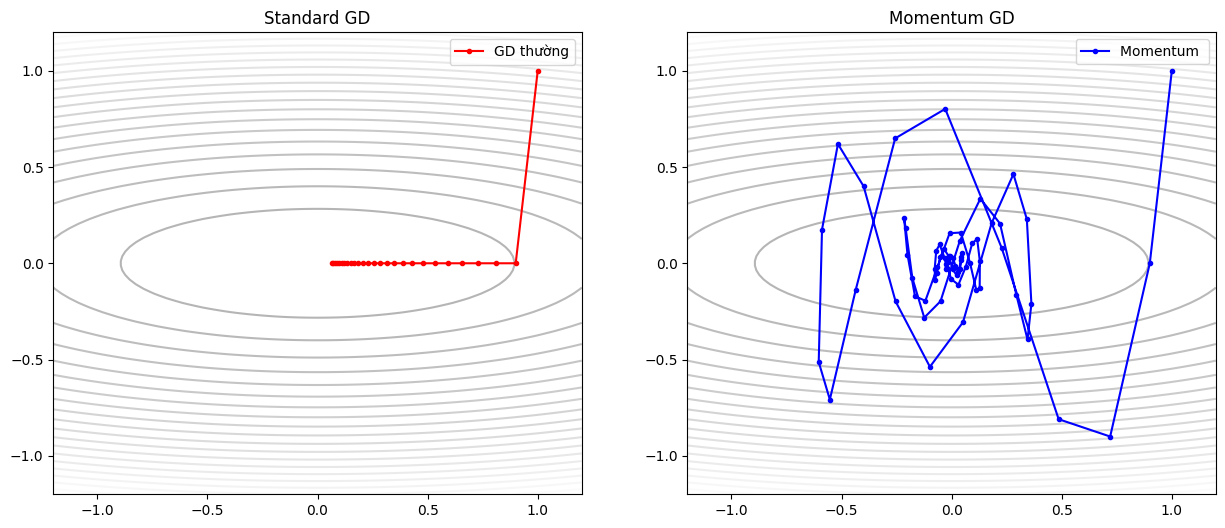

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x = np.linspace(-1.2, 1.2, 100)
y = np.linspace(-1.2, 1.2, 100)
X, Y = np.meshgrid(x, y)
Z = f_elip(X, Y)

#g1
ax[0].contour(X, Y, Z, levels=20, cmap='gray', alpha=0.3)
ax[0].plot(path_gd[:,0], path_gd[:,1], 'r.-', label='GD thường')
ax[0].set_title('Standard GD')
ax[0].legend()

#g2
ax[1].contour(X, Y, Z, levels=20, cmap='gray', alpha=0.3)
ax[1].plot(path_momentum[:,0], path_momentum[:,1], 'b.-', label='Momentum ')
ax[1].set_title('Momentum GD')
ax[1].legend()

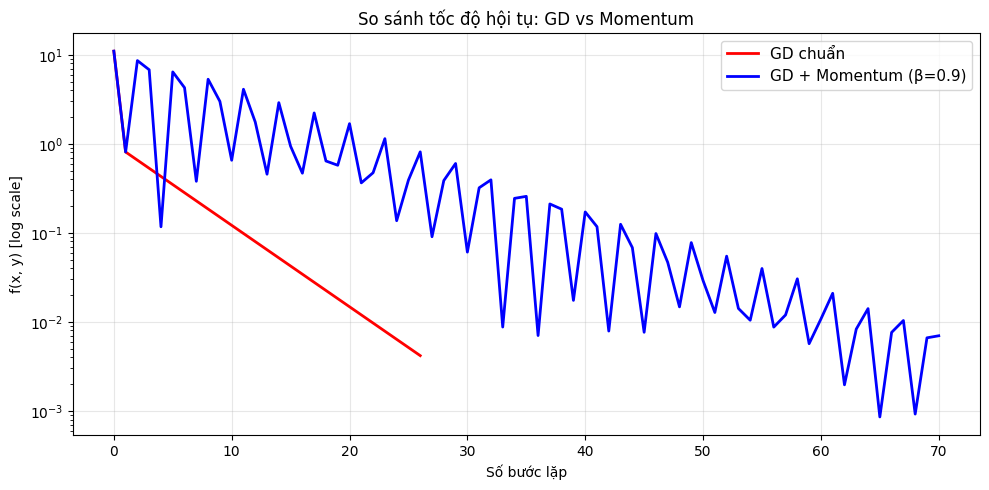

In [15]:
losses_gd_full = [f_elip(p[0], p[1]) for p in path_gd]
losses_mom = [f_elip(p[0], p[1]) for p in path_momentum]

plt.figure(figsize=(10, 5))
plt.semilogy(losses_gd_full, 'r-', linewidth=2, label='GD chuẩn')
plt.semilogy(losses_mom, 'b-', linewidth=2, label='GD + Momentum (β=0.9)')
plt.xlabel('Số bước lặp')
plt.ylabel('f(x, y) [log scale]')
plt.title('So sánh tốc độ hội tụ: GD vs Momentum')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 2.3 Phân tích ảnh hưởng của Beta

In [16]:
lr = 0.001
iter = 200
start_pos = np.array([1.0, 1.0])
flag = False

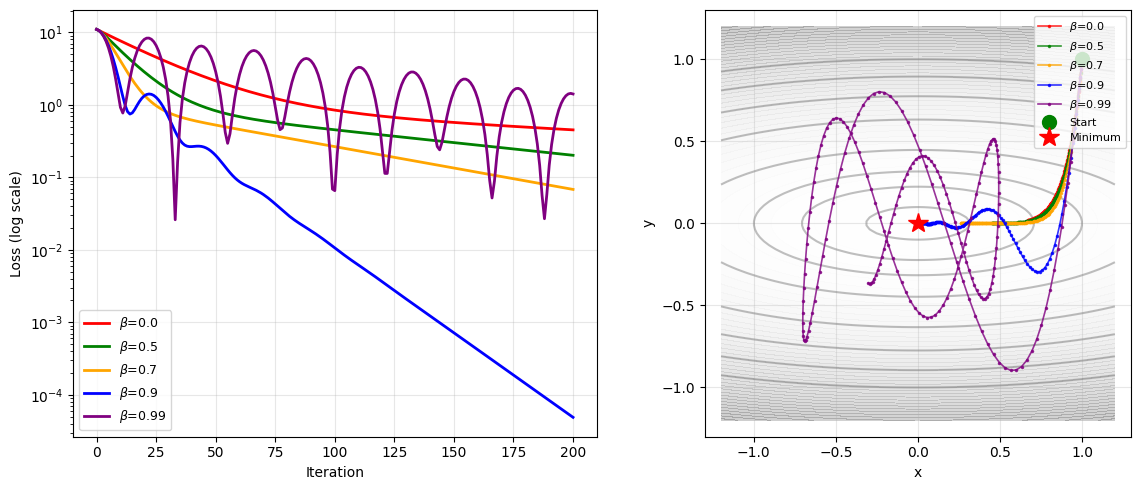

In [17]:
#beta_values = [0.0, 0.5, 0.7]
beta_values = [0.0, 0.5, 0.7, 0.9, 0.99]
colors = ['red', 'green', 'orange', 'blue', 'purple']

plt.figure(figsize=(12, 5))

# Sub1
plt.subplot(1, 2, 1)
for beta, color in zip(beta_values, colors):
    if beta == 0.0:
        path = simple_gd(start_pos, lr=lr, iterations=iter, cond = flag)
    else:
        path = simple_m(start_pos, lr=lr, gamma=beta, iterations=iter, cond = flag)

    losses = [f_elip(p[0], p[1]) for p in path]
    label = fr'$\beta$={beta}'
    plt.semilogy(losses, '-', color=color, linewidth=2, label=label)

plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Sub2
plt.subplot(1, 2, 2)
plt.contour(X, Y, Z, levels=levels, colors='gray', alpha=0.5)
plt.contourf(X, Y, Z, levels=50, cmap='Greys', alpha=0.2)

for beta, color in zip(beta_values, colors):
    if beta == 0.0:
        path = simple_gd(start_pos, lr=lr, iterations=iter, cond = flag)
    else:
        path = simple_m(start_pos, lr=lr, gamma=beta, iterations=iter, cond = flag)

    plt.plot(path[:, 0], path[:, 1], '.-', color=color, markersize=3,
             linewidth=1.2, alpha=0.8, label=fr'$\beta$={beta}')

plt.plot(1.0, 1.0, 'go', markersize=10, zorder=5, label='Start')
plt.plot(0, 0, 'r*', markersize=15, zorder=5, label='Minimum')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(fontsize=8, loc='upper right')
plt.xlim(-1.3, 1.3); plt.ylim(-1.3, 1.3)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



| Giá trị β | Hành vi |
|---|---|
| β = 0 | Tương đương GD chuẩn (không có momentum) |
| β = 0.5 | Momentum yếu, giảm nhẹ zig-zag |
| β = 0.9 | **Momentum tốt** – giá trị phổ biến nhất |
| β = 0.99 | Momentum rất mạnh – có thể dao động do quán tính lớn |

**Nguy hiểm khi β quá lớn**: Thuật toán có thể "vượt qua" điểm cực tiểu và dao động (overshooting), tương tự learning rate quá lớn.


---
# III. NESTEROV ACCELERATED GRADIENT (NAG)

### 3.1 Hạn chế của Momentum thuần túy

Momentum chuẩn có một điểm yếu: nó tính gradient **tại vị trí hiện tại** $\mathbf{x}_t$, nhưng thực ra bước nhảy sẽ đưa chúng ta đến gần vị trí $\mathbf{x}_t - \gamma \mathbf{v}_{t-1}$ hơn. Điều này gây ra hiện tượng **"nhìn thấy muộn"** – thuật toán đang ở một hướng nhưng gradient lại đo ở chỗ cũ.

### 3.2 Ý tưởng của Nesterov (1983)

> **Ý tưởng**: Thay vì tính gradient ở **vị trí hiện tại**, hãy tính gradient ở **vị trí "nhìn trước"** (look-ahead position) – nơi mà momentum sẽ đưa chúng ta đến.

### 3.3 Công thức toán học

**Bước "nhìn trước" (look-ahead):**
$$\tilde{\mathbf{x}}_t = \mathbf{x}_t - \gamma \mathbf{v}_{t-1}$$

**Cập nhật vận tốc tại vị trí nhìn trước:**
$$\mathbf{v}_t = \gamma \mathbf{v}_{t-1} + \eta \nabla f(\mathbf{x}_t - \gamma \mathbf{v}_{t-1})$$

**Cập nhật vị trí:**
$$\mathbf{x}_{t+1} = \mathbf{x}_t - \mathbf{v}_{t}$$

### 3.4 So sánh Momentum vs Nesterov

| | Momentum | Nesterov (NAG) |
|---|---|---|
| **Tính gradient tại** | $\mathbf{x}_t$ (hiện tại) | $\mathbf{x}_t + \beta \mathbf{v}_t$ (nhìn trước) |
| **Hiệu chỉnh** | Phản ứng chậm với thay đổi | Phản ứng nhanh hơn |
| **Lý thuyết** | Không có đảm bảo hội tụ tốt | Đảm bảo $O(1/T^2)$ cho hàm lồi |
| **Thực tế** | Tốt | Thường tốt hơn một chút |


In [18]:
def nesterov_gd(x_init, y_init, lr, beta, n_steps, tol=1e-6, cond = True):
    path = [[x_init, y_init]]
    x, y = x_init, y_init
    vx, vy = 0.0, 0.0
    prev_loss = f_elip(x, y)

    for i in range(n_steps):
        # Look-ahead
        x_tilde = x + beta * vx
        y_tilde = y + beta * vy

        # grad
        g = grad_elip(x_tilde, y_tilde)

        # Update velocity
        vx = beta * vx - lr * g[0]
        vy = beta * vy - lr * g[1]

        # Update position
        x += vx
        y += vy

        path.append([x, y])

        cur_loss = f_elip(x, y)
        if abs(prev_loss - cur_loss) < tol and cond:
            print(f"Stop at round {i}")
            break
        prev_loss = cur_loss

    return np.array(path)

In [19]:
start_x, start_y = 1.0, 1.0
start_pos = np.array([start_x, start_y])
lr = 0.01
beta = 0.9
n_steps = 100
n_show = 50
flag = False

In [20]:
path_gd = simple_gd(start_pos, lr, n_steps, cond = flag)
path_mom = simple_m(start_pos, lr, beta, n_steps, cond = flag)
path_nag = nesterov_gd(start_x, start_y, lr, beta, n_steps, cond = flag)
losses_gd = [f_elip(p[0], p[1]) for p in path_gd]
losses_mom = [f_elip(p[0], p[1]) for p in path_mom]
losses_nag = [f_elip(p[0], p[1]) for p in path_nag]

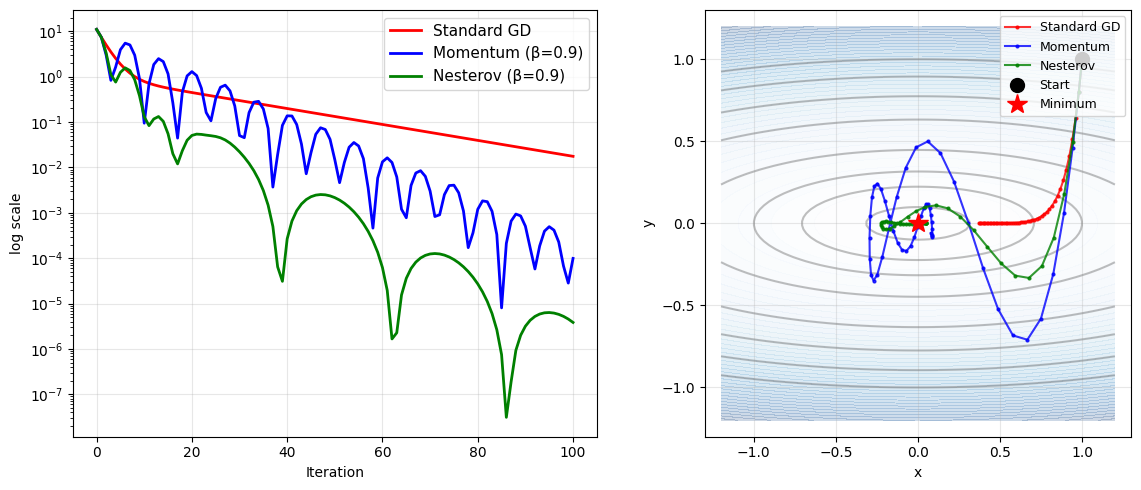

In [21]:
plt.figure(figsize=(12, 5))

# S1
plt.subplot(1, 2, 1)
plt.semilogy(losses_gd, 'r-', linewidth=2, label='Standard GD')
plt.semilogy(losses_mom, 'b-', linewidth=2, label=f'Momentum (β={beta})')
plt.semilogy(losses_nag, 'g-', linewidth=2, label=f'Nesterov (β={beta})')
plt.xlabel('Iteration')
plt.ylabel('log scale')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# S2
plt.subplot(1, 2, 2)
plt.contour(X, Y, Z, levels=levels, colors='gray', alpha=0.5)
plt.contourf(X, Y, Z, levels=50, cmap='Blues', alpha=0.2)

plt.plot(path_gd[:n_show, 0], path_gd[:n_show, 1], 'r.-', markersize=4,
         linewidth=1.5, label='Standard GD', alpha=0.8)
plt.plot(path_mom[:n_show, 0], path_mom[:n_show, 1], 'b.-', markersize=4,
         linewidth=1.5, label='Momentum', alpha=0.8)
plt.plot(path_nag[:n_show, 0], path_nag[:n_show, 1], 'g.-', markersize=4,
         linewidth=1.5, label='Nesterov', alpha=0.8)

plt.plot(start_x, start_y, 'ko', markersize=10, zorder=5, label='Start')
plt.plot(0, 0, 'r*', markersize=15, zorder=5, label='Minimum')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize=9, loc='upper right')
plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# IV. Bài tập

## Câu 1:
Cho hàm số sau $f(x,y) = (1 - x)^2 + 100(y - x^2)^2$. Hãy:


*   Viết hàm `rosenbrock(x, y)` tính giá trị hàm mục tiêu và hàm `rosenbrock_grad(x, y)` trả về vector gradient $\nabla f(x,y)$.
*   Khởi tạo điểm bắt đầu $x_0 = (-2, 2)$. Cài đặt thuật toán tối ưu hóa tìm điểm cực tiểu bằng ba phương pháp với số `epochs = 1000`:
    *   Batch Gradient Descent
    *   Batch Gradient Descent + Momentum
    *   Batch Gradient Descent + Nesterov Accelerated Gradient (NAG)
*   Vẽ contour plot của hàm số và biểu diễn quỹ đạo di chuyển của ba thuật toán trên cùng một biểu đồ. In ra tọa độ hội tụ cuối cùng của từng phương pháp.

In [22]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100*(y - x**2)**2

def rosenbrock_grad(x, y):
    return np.array([2*(x - 1) + 400*x*(x**2 - y), 200*(y - x**2)])

In [23]:
def simple_gd(start_pos, lr, n_steps, tol=1e-3, cond = True):
    path = [start_pos.copy()]
    curr = start_pos.copy()
    prev_loss = rosenbrock(curr[0], curr[1])

    for i in range(n_steps):
        g = rosenbrock_grad(curr[0], curr[1])
        curr -= lr * g
        path.append(curr.copy())

        cur_loss = rosenbrock(curr[0], curr[1])
        if abs(prev_loss - cur_loss) < tol and cond:
            print(f" Stop at round {i}")
            break
        prev_loss = cur_loss

    return np.array(path)

def simple_m(start_pos, lr, gamma, n_steps, tol=1e-3, cond = True):
    path = [start_pos.copy()]
    curr = start_pos.copy()
    v = np.zeros_like(start_pos)
    prev_loss = rosenbrock(curr[0], curr[1])

    for i in range(n_steps):
        g = rosenbrock_grad(curr[0], curr[1])
        v = gamma * v + lr * g
        curr -= v
        path.append(curr.copy())

        cur_loss = rosenbrock(curr[0], curr[1])
        if abs(prev_loss - cur_loss) < tol and cond:
            print(f" Stop at round {i}")
            break
        prev_loss = cur_loss

    return np.array(path)

def nesterov_gd(x_init, y_init, lr, beta, n_steps, tol=1e-6, cond = True):
    path = [[x_init, y_init]]
    x, y = x_init, y_init
    vx, vy = 0.0, 0.0
    prev_loss = rosenbrock(x, y)

    for i in range(n_steps):
        # Look-ahead
        x_tilde = x + beta * vx
        y_tilde = y + beta * vy

        # grad
        g = rosenbrock_grad(x_tilde, y_tilde)

        # Update velocity
        vx = beta * vx - lr * g[0]
        vy = beta * vy - lr * g[1]

        # Update position
        x += vx
        y += vy

        path.append([x, y])

        cur_loss = rosenbrock(x, y)
        if abs(prev_loss - cur_loss) < tol and cond:
            print(f"Stop at round {i}")
            break
        prev_loss = cur_loss

    return np.array(path)

In [63]:
start_x, start_y = -2.0, 2.0
start_pos = np.array([start_x, start_y])
lr = 0.0005
beta = 0.9
n_steps = 1000
n_show = 50
flag = False

path_gd = simple_gd(start_pos, lr, n_steps, cond=flag)
path_mom = simple_m(start_pos, lr, beta, n_steps, cond=flag)
path_nag = nesterov_gd(start_x, start_y, lr, beta, n_steps, cond = flag)

losses_gd = [rosenbrock(p[0], p[1]) for p in path_gd]
losses_mom = [rosenbrock(p[0], p[1]) for p in path_mom]
losses_nag = [rosenbrock(p[0], p[1]) for p in path_nag]

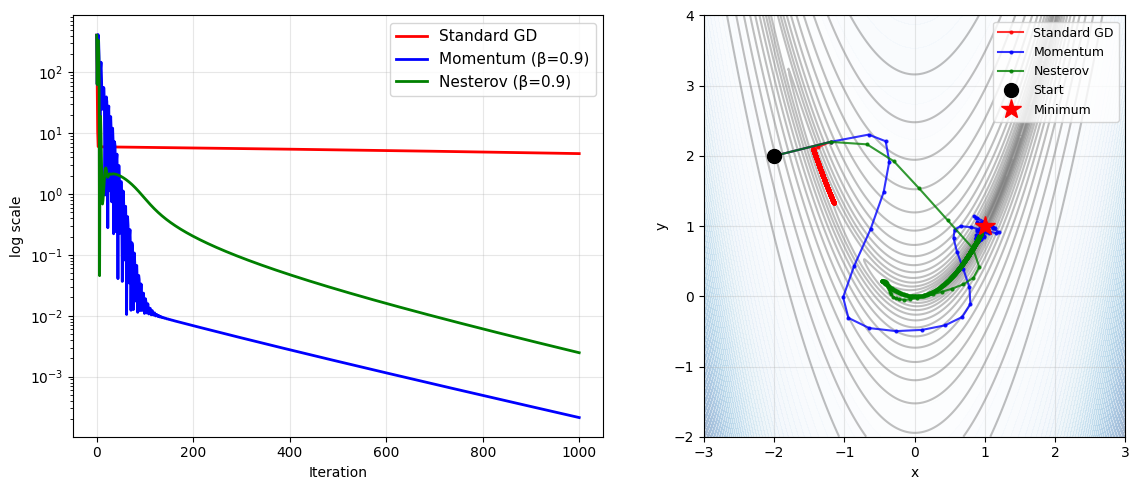

In [66]:
plt.figure(figsize=(12, 5))

# S1
plt.subplot(1, 2, 1)
plt.semilogy(losses_gd, 'r-', linewidth=2, label='Standard GD')
plt.semilogy(losses_mom, 'b-', linewidth=2, label=f'Momentum (β={beta})')
plt.semilogy(losses_nag, 'g-', linewidth=2, label=f'Nesterov (β={beta})')
plt.xlabel('Iteration')
plt.ylabel('log scale')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# S2
plt.subplot(1, 2, 2)
x = np.linspace(-3, 3, 400)
y = np.linspace(-2, 4, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), colors='gray', alpha=0.5)
plt.contourf(X, Y, Z, levels=50, cmap='Blues', alpha=0.2)

plt.plot(path_gd[:, 0], path_gd[:, 1], 'r.-',  markersize=4,
         linewidth=1.5, label='Standard GD', alpha=0.8)
plt.plot(path_mom[:, 0], path_mom[:, 1], 'b.-',  markersize=4,
         linewidth=1.5, label='Momentum', alpha=0.8)
plt.plot(path_nag[:, 0], path_nag[:, 1], 'g.-',  markersize=4,
         linewidth=1.5, label='Nesterov', alpha=0.8)

plt.plot(start_pos[0], start_pos[1], 'ko', markersize=10, zorder=5, label='Start')
plt.plot(1, 1, 'r*', markersize=15, zorder=5, label='Minimum')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize=9)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Câu 2:
Cho điểm dữ liệu thứ $i$ có vector đặc trưng $\mathbf{x}^{(i)}$ và nhãn $y^{(i)} \in \{0, 1\}$. Ma trận trọng số là $\mathbf{w}$. Hãy giải quyết các vấn đề sau:



1.   Tạo tập dữ liệu bằng sklearn.datasets.make_classification ($N=1000$, 2 features), chia Train/Test tỉ lệ 80/20. Cố định batch_size = 32. Sử dụng hàm `train_test_split` từ `sklearn.model_selection` để chia X và y thành các tập `X_train`, `X_test`, `y_train`, `y_test` với tỉ lệ 80% dùng để huấn luyện (`test_size=0.2`).

2.   Cài đặt hàm `create_mini_batches(X, y, batch_size)`: Thực hiện xáo trộn ngẫu nhiên và cắt tập dữ liệu thành các `batch`.

3.   Cài đặt hàm tính Binary Cross-Entropy Loss $J(\mathbf{w})$ và vector gradient $\nabla_{\mathbf{w}} J(\mathbf{w})$ trung bình trên một mini-batch có kích thước $m$ `compute_grads(X_b, y_b, w)`:

$$
J(\mathbf{w}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

$$\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \mathbf{x}^{(i)}
$$

   Biết rằng:

$$\hat{y}^{(i)} = \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}^{(i)}}}$$



4.    Giải quyết bài toán trên sử dụng 3 thuật toán với các siêu tham số lần lượt là `epochs = 50`, `lr = 0.01`, `gamma = 0.9`, `batch_size = 64`:
      *   Mini-Batch GD (MBGD)
      *   MBGD + Momentum.
      *   MBGD + Nesterov.

    Guide:
    for _ in epoch:
        batches = create_mini_batches(X_train, y_train, batch_size)
        for _ in batches:
            loss,grad = compute_loss_grad(X_b, y_b, w_mbgd)
            -> Update theo 3 thuật toán yêu cầu, lưu ý grad của cả 3 là độc lập

5. Vẽ đồ thị Loss Curve của ba thuật toán.





In [147]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
def create_mini_batches(X, y, batch_size):
    indices = np.random.permutation(X.shape[0])
    X_shuffled, y_shuffled = X[indices], y[indices]
    for i in range(0, X.shape[0], batch_size):
        yield X_shuffled[i : i + batch_size], y_shuffled[i : i + batch_size]

In [149]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_grads(X_batch, y_batch, w):
    y_hat = sigmoid(X_batch @ w)

    m = X_batch.shape[0]
    epsilon = 1e-15

    loss = -1/m * np.sum(y_batch * np.log(y_hat + epsilon) + (1 - y_batch) * np.log(1 - y_hat + epsilon))
    grad = 1/m * X_batch.T @ (y_hat - y_batch)
    
    return loss, grad

In [158]:
epochs = 50
lr = 0.01
gamma = 0.9
batch_size = 64

np.random.seed(1)
w_gd = np.zeros(X_train.shape[1])
w_mom  = np.zeros(X_train.shape[1])
w_nag  = np.zeros(X_train.shape[1])

v_mom = np.zeros(X_train.shape[1])
v_nag = np.zeros(X_train.shape[1])

path_loss_gd = []
path_loss_mom = []
path_loss_nag = []

for epoch in range(epochs):

    batches = list(create_mini_batches(X_train, y_train, batch_size=64))

    loss_gd, loss_mom, loss_nag = 0, 0, 0

    for X_batch, y_batch in batches:
        # GD
        loss, grad = compute_grads(X_batch, y_batch, w_gd)
        w_gd -= lr * grad
        loss_gd += loss

        # Momentum
        loss, grad = compute_grads(X_batch, y_batch, w_mom)
        v_mom = gamma * v_mom + lr * grad
        w_mom -= v_mom
        loss_mom += loss

        # NAG
        loss, grad = compute_grads(X_batch, y_batch, w_nag - gamma * v_nag)
        v_nag = gamma * v_nag + lr * grad
        w_nag -= v_nag
        loss, grad = compute_grads(X_batch, y_batch, w_nag)
        loss_nag += loss

    path_loss_gd.append(loss_gd / len(batches))
    path_loss_mom.append(loss_mom / len(batches))
    path_loss_nag.append(loss_nag / len(batches))

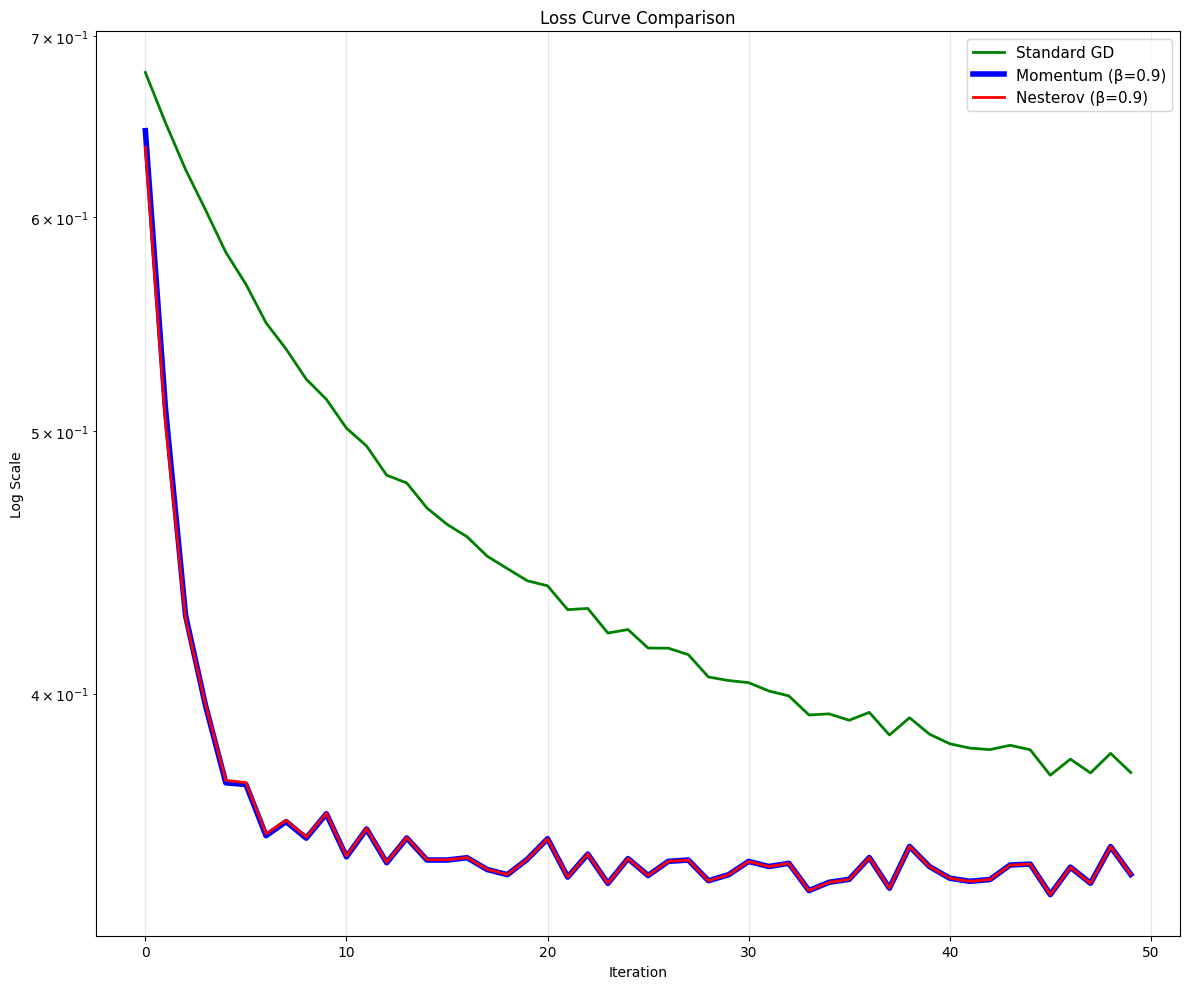

In [159]:
plt.figure(figsize=(12, 10))

plt.semilogy(path_loss_gd, 'g-', linewidth=2, label='Standard GD')
plt.semilogy(path_loss_mom, 'b-', linewidth=4, label=f'Momentum (β={gamma})')
plt.semilogy(path_loss_nag, 'r-', linewidth=2, label=f'Nesterov (β={gamma})')

plt.xlabel('Iteration') 
plt.ylabel('Log Scale')
plt.title('Loss Curve Comparison')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Câu 3:
1.   Cố định `lr = 0.01`, `epochs = 50` và `batch_size = 32`.
2.   Thực thi thuật toán MBGD + Momentum trên bài toán ở Bài 2 với các giá trị $\gamma \in \{0.1, 0.5, 0.9, 0.99\}$.
3.   Vẽ đồ thị Loss Curve tương ứng cho từng cấu hình $\gamma$ lên cùng một biểu đồ.


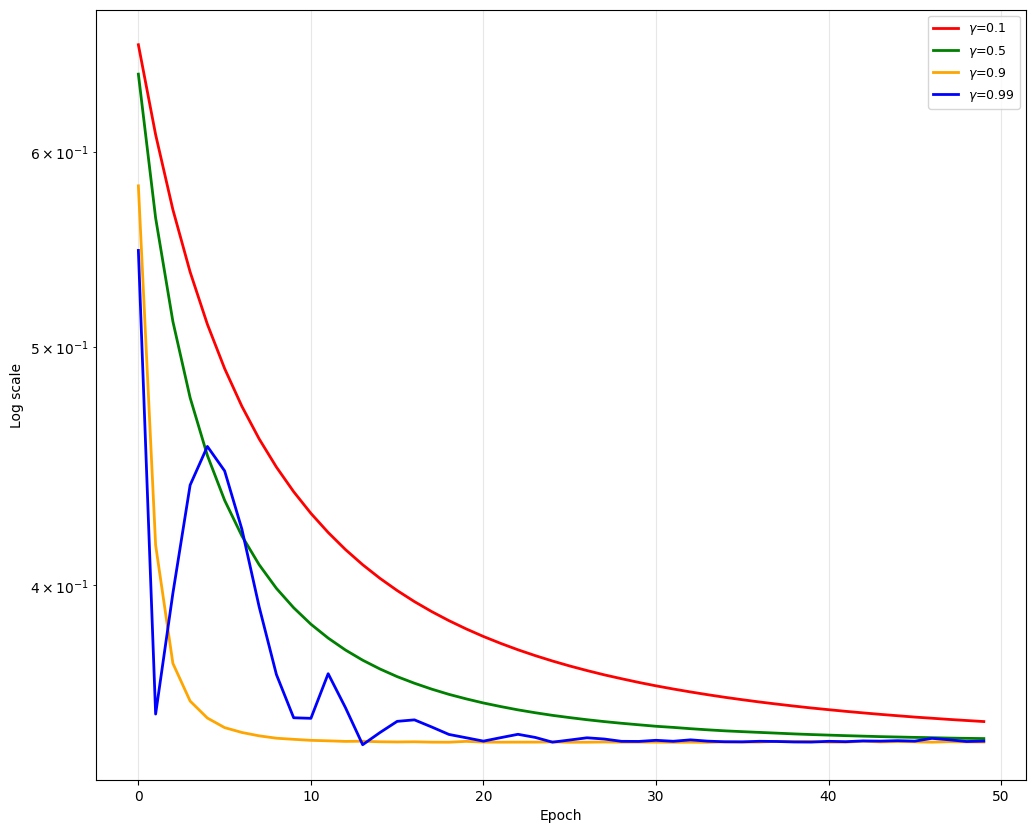

In [160]:
lr = 0.01
epochs = 50
batch_size = 32
gamma_list = [0.1, 0.5, 0.9, 0.99]
colors = ['red', 'green', 'orange', 'blue']

plt.figure(figsize=(12, 10))

for gamma, color in zip(gamma_list, colors):
    w = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])
    losses = []

    for epoch in range(epochs):
        batches = list(create_mini_batches(X_train, y_train, batch_size))
        loss_sum = 0
        
        for X_batch, y_batch in batches:
            loss, grad = compute_grads(X_batch, y_batch, w)
            v = gamma * v + lr * grad
            w -= v
            loss_sum += loss
            
        losses.append(loss_sum / len(batches))

    plt.semilogy(losses, '-', color=color, linewidth=2, label=fr'$\gamma$={gamma}')

plt.xlabel('Epoch')
plt.ylabel('Log scale')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

## Câu 4:
1.   Sử dụng thuật toán MBGD + Momentum trên tập dữ liệu ở Bài 2. Sử dụng thư viện `time` để đo thời gian thực thi của vòng lặp huấn luyện.

2.   Huấn luyện mô hình trong đúng 50 epochs với 4 cấu hình batch_size khác nhau: `epoch` $\in \{1, 32, 128, Full\}$. Các siêu tham số sử dụng lần lượt là `epochs = 50`, `lr = 0.01`, `gamma = 0.9`.
3.   Vẽ 4 đường Loss Curve trên cùng một biểu đồ. In ra thời gian huấn luyện tổng cộng của từng cấu hình.




Batch_size = 1: 1.2588 seconds
Batch_size = 32: 0.0417 seconds
Batch_size = 128: 0.0144 seconds
Batch_size = 800: 0.0055 seconds


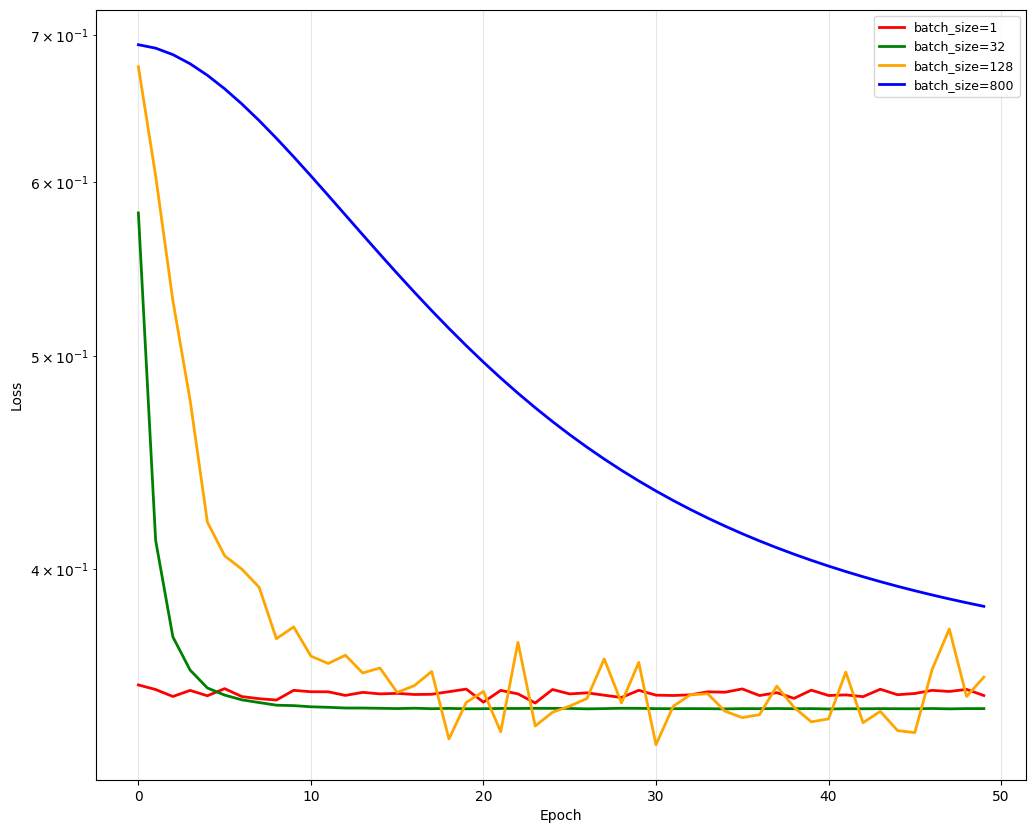

In [161]:
import time

batch_size_list = [1, 32, 128, X_train.shape[0]]
lr = 0.01
epochs = 50
gamma = 0.9
colors = ['red', 'green', 'orange', 'blue']

plt.figure(figsize=(12, 10))

for batch_size, color in zip(batch_size_list, colors):
    w = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])
    losses = []

    start_time = time.time()

    for epoch in range(epochs):
        batches = list(create_mini_batches(X_train, y_train, batch_size))
        loss_sum = 0
        
        for X_batch, y_batch in batches:
            loss, grad = compute_grads(X_batch, y_batch, w)
            v = gamma * v + lr * grad
            w -= v
            loss_sum += loss
            
        losses.append(loss_sum / len(batches))

    end_time = time.time()
    print(f"Batch_size = {batch_size}: {end_time - start_time:.4f} seconds")
    
    plt.semilogy(losses, '-', color=color, linewidth=2, label=f'batch_size={batch_size}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()